# Análisis Predictivo - Evaluación 1

## Part 1 (1 point)

Cargue el archivo dado, que contiene un dataset cuya información puede consultar en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

Verifique que los tipos de dato que Pandas asigno a cada variable sean correctos.

Indique en una celda de texto cuántas variables y registros tiene el dataset, y que variables contienen datos nulos.

---

Load the given file, which contains a dataset whose information you can query at [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

Verify that the data types that Pandas assigned to each variable are correct.

Indicate in a text cell how many variables and records the dataset has, and which variables contain null data.

In [2]:
from pathlib import Path

import pandas as pd
    
ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'athlete_events.csv'

df = pd.read_csv(DATA_DIR / file_path)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


Creo que age,height no deben de ser float64 si no int64, no tienen decimales datos con decimales,pero los esta tomando float64 por tener nulos.

In [5]:
df.isnull().sum().sort_values(ascending=False).head(5)

Medal     231333
Weight     62875
Height     60171
Age         9474
Sex            0
dtype: int64

Tiene 15 variables, 271116 entradas y hay 4 variables que tienen datos nulos.

Medal, Weitgh, Height y Age

Identifique las variables categóricas que tienen una cardinalidad superior a 200, y elimínelas del dataframe. Considere la variable **ID** como categórica.

---

Identify categorical variables that have a cardinality greater than 200, and remove them from the dataframe. Consider the variable **ID** as categorical.

In [7]:
df.astype({'ID': 'object'}).describe(include='object').T

,count,unique,top,freq
ID,271116,135571,77710,58
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733


Las variables de alta cardinalidad son ID, Name,Team, NOC, Event

In [8]:
df = df.drop(columns=['ID', 'Name', 'Team', 'NOC', 'Event'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     271116 non-null  object 
 1   Age     261642 non-null  float64
 2   Height  210945 non-null  float64
 3   Weight  208241 non-null  float64
 4   Games   271116 non-null  object 
 5   Year    271116 non-null  int64  
 6   Season  271116 non-null  object 
 7   City    271116 non-null  object 
 8   Sport   271116 non-null  object 
 9   Medal   39783 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 20.7+ MB


Impute a los datos nulos de la variable **Medal** la categoría **No medal**.

---

Impute  the category **No medal** to the null data of the variable **Medal**.

In [9]:
df['Medal'].fillna(value='No medal').loc[1:6]

1    No medal
2    No medal
3        Gold
4    No medal
5    No medal
6    No medal
Name: Medal, dtype: object

## Part 2 (1.5 points)

Se van a preparar los datos para posteriormente entrenar un modelo de aprendizaje de máquina que prediga la variable **Weight**, que es el peso de los atletas.

Haga un análisis exploratorio centrado en identificar como se comportan las demás variables de su dataset con respecto a la variable que se va a predecir. Utilice estadísticas descriptivas o gráficas para hacer este análisis.

Indique que variables, de acuerdo a este análisis, serían las mejores predictoras del peso de un atleta.

**Presente en celdas de texto los resultados de sus análisis**.

---

The data will be prepared to later train a machine learning model that predicts the variable **Weight**, which is the weight of the athletes.

Do an exploratory analysis focused on identifying how the other variables in your dataset behave with respect to the variable to be predicted. Use descriptive statistics or graphics to do this analysis.

Indicate which variables, according to this analysis, would be the best predictors of an athlete's weight.

**Present the results of your analysis in text cells**.



<Axes: >

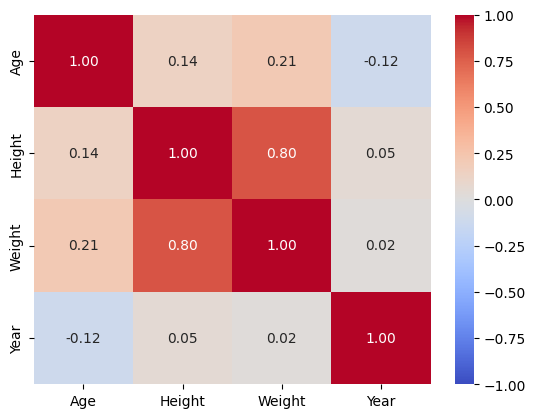

In [15]:
#Numericas
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

--- Análisis de Weight según Sex ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


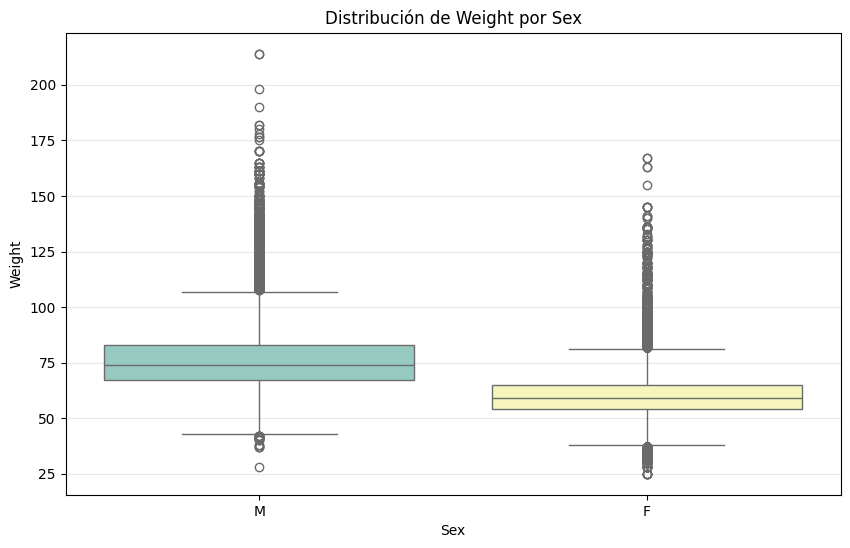

,Weight
Sex,
M,75.743677
F,60.021252


--------------------------------------------------
--- Análisis de Weight según Games ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


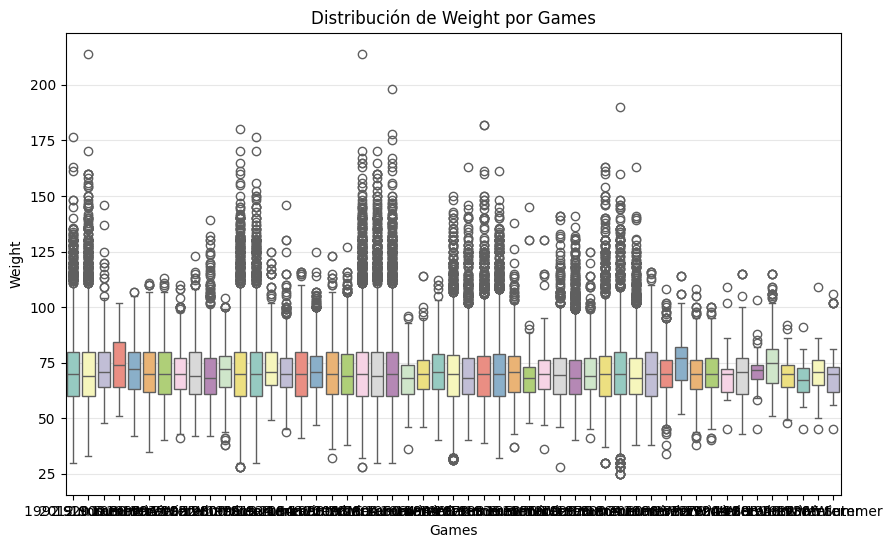

,Weight
Games,
1906 Summer,75.917073
1908 Summer,75.386128
1900 Summer,74.556962
1912 Summer,73.117450
1920 Summer,73.106157
1904 Summer,72.197279
1988 Winter,72.002725
1948 Summer,71.942308
1924 Summer,71.812018


--------------------------------------------------
--- Análisis de Weight según Season ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


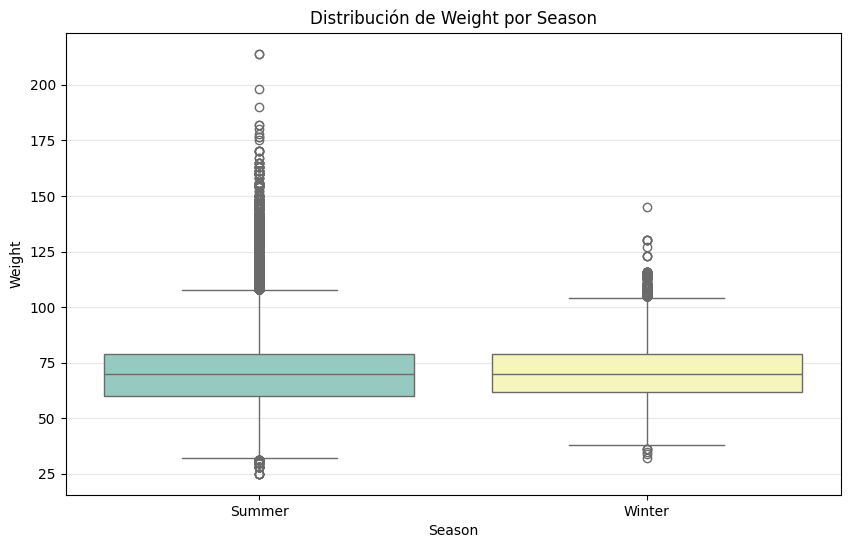

,Weight
Season,
Winter,70.759275
Summer,70.689060


--------------------------------------------------
--- Análisis de Weight según City ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


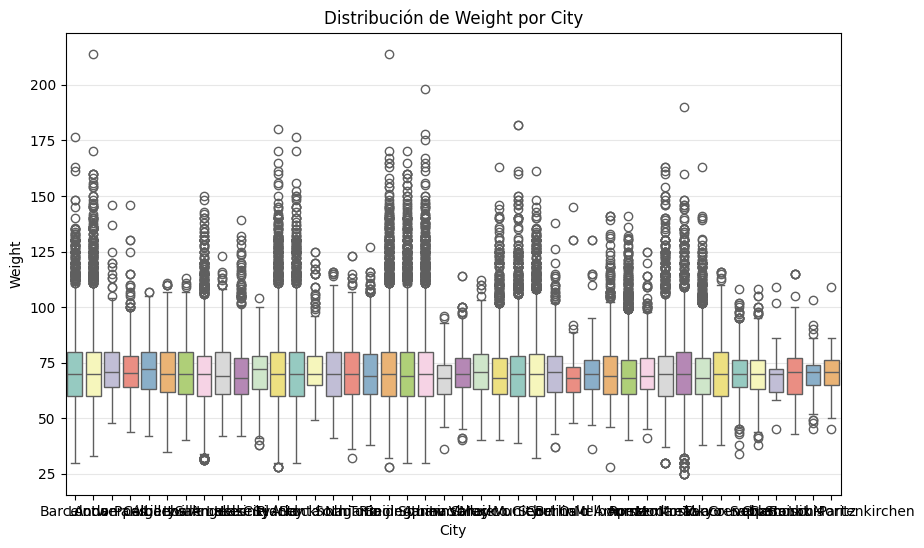

,Weight
City,
Antwerpen,73.106157
Stockholm,72.562678
St. Louis,72.197279
Paris,72.109890
Calgary,72.002725
Berlin,71.630363
London,71.505042
Beijing,71.397679
Athina,71.350659


--------------------------------------------------
--- Análisis de Weight según Sport ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


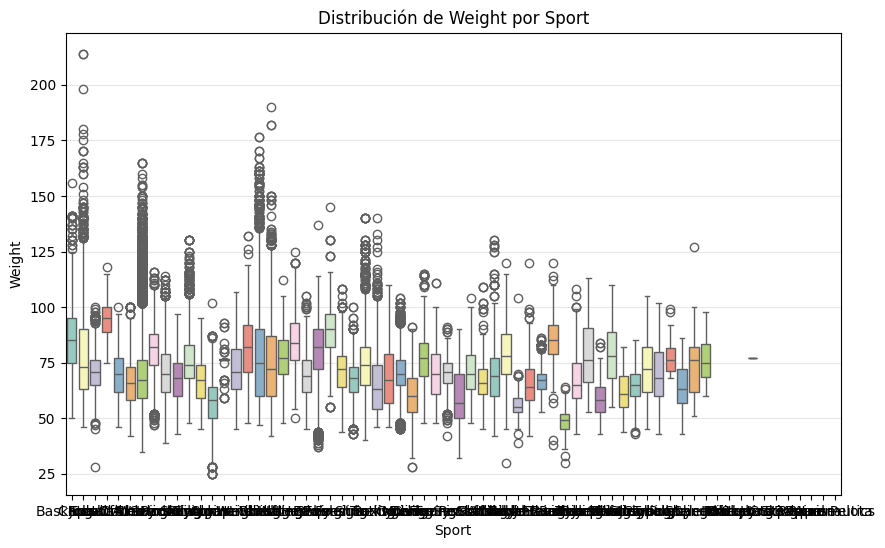

,Weight
Sport,
Tug-Of-War,95.615385
Bobsleigh,89.250678
Basketball,85.777053
Baseball,85.707792
Water Polo,84.566446
...,...
Jeu De Paume,NaN
Military Ski Patrol,NaN
Polo,NaN


--------------------------------------------------
--- Análisis de Weight según Medal ---


/var/folders/_l/gfl4k6dx59qdvqn1k_hr93f40000gp/T/ipykernel_2125/4178818751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='Weight', palette='Set3')


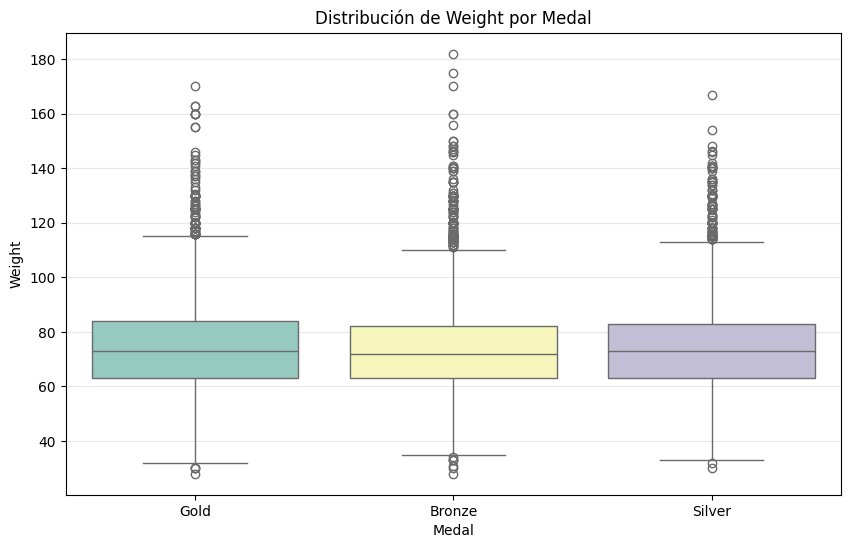

,Weight
Medal,
Gold,74.183879
Silver,73.644962
Bronze,73.479010


--------------------------------------------------


In [17]:
cat_vars = df.select_dtypes(include=['object']).columns.tolist()
for var in cat_vars:
    print(f"--- Análisis de Weight según {var} ---")
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=var, y='Weight', palette='Set3')
    plt.title(f'Distribución de Weight por {var}')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Mostramos la media de peso por categoría para confirmar
    display(df.groupby(var)['Weight'].mean().to_frame().sort_values(by='Weight', ascending=False))
    print("-" * 50)

Son buenos preditores segun las graficas

Numericas:

Categoricas: 

## Part 3 (2.5 points)

Cree un nuevo dataframe con las siguientes variables: **Age, Height, Sport, Sex, Weight**.

Elimine los datos nulos de la variable **Weight**.

Impute a los datos nulos de las variables **Age** y **Height** la media de la variable correspondiente agrupada por etiqueta de la variable **Sport**.

Elimine **únicamente** los valores atípicos altos de la variable **Age**.

---

Create a new dataframe with the following variables: **Age, Height, Sport, Sex, Weight**.

Remove null data from the **Weight** variable.

Impute to the null data of the variables **Age** and **Height** the mean of the corresponding variable grouped by label of the variable **Sport**.

Eliminate **only** high outliers from the **Age** variable.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer
import numpy as np

df_model = df[['Age', 'Height', 'Sport', 'Sex', 'Weight']].dropna(subset=['Weight']).copy()

df_model.info()
#me aseguro de que no haya nulos en weight
df_model.isnull().sum().sort_values(ascending=False).head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 208241 entries, 0 to 271115
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Age     207379 non-null  float64
 1   Height  206853 non-null  float64
 2   Sport   208241 non-null  object 
 3   Sex     208241 non-null  object 
 4   Weight  208241 non-null  float64
dtypes: float64(3), object(2)
memory usage: 9.5+ MB


Height    1388
Age        862
Sport        0
Sex          0
Weight       0
dtype: int64

In [28]:
df_model['Age'].fillna(df.groupby('Sport')['Age'].transform(lambda x: x.mean()))


0         24.0
1         23.0
4         21.0
5         21.0
6         25.0
          ... 
271111    29.0
271112    27.0
271113    27.0
271114    30.0
271115    34.0
Name: Age, Length: 208241, dtype: float64

In [24]:
df_model['Height'].fillna(df.groupby('Sport')['Height'].transform(lambda x: x.mean()))

0         180.0
1         170.0
4         185.0
5         185.0
6         185.0
          ...  
271111    179.0
271112    176.0
271113    176.0
271114    185.0
271115    185.0
Name: Height, Length: 208241, dtype: float64

<Axes: >

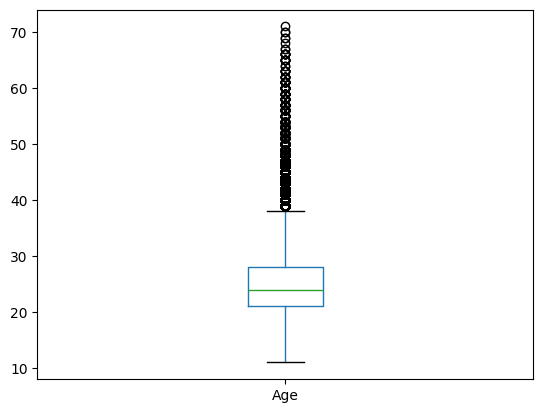

In [40]:
df_model.boxplot('Age', grid=False)

In [33]:
print('Número de registros: ', df_model.shape[0])

Número de registros:  208241


In [39]:
df3 = df_model.copy()
Q1 = df3['Age'].quantile(0.25)
Q3 = df3['Age'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5*IQR
#lower_limit = Q1 - 1.5*IQR este no por que piden solo los altos
df3 = df3[(df3['Age'] < upper_limit)]
print('Número de registros: ', df3.shape[0])

Número de registros:  202694


Cree la matriz de características (habitualmente llamada **X**) y el vector objetivo (habitualmente llamado **y**).

Parta los datos en conjuntos de entrenamiento y prueba en una proporción 80/20.

---

Create the feature matrix (usually called **X**) and the target vector (usually called **y**).

Split the data into training and test sets in an 80/20 ratio.


In [52]:
X = df3.drop(columns=['Weight'])
y = df3['Weight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (162155, 4)
Tamaño del conjunto de prueba es: (40539, 4)


Codifique la variable **Sport**, conservando únicamente las categorías con frecuencia relativa mayor al 1%, y agrupando las otras en una sola categoría.

---

Code the **Sport** variable, keeping only the categories with a relative frequency greater than 1%, and grouping the others into a single category.

In [53]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
df_sporte= df3[['Sport']]

ohe = OneHotEncoder(
    sparse_output=False,
    min_frequency=0.01 
    )

sport_cod = ohe.fit_transform(df_sporte)

df_sporte_cod = pd.DataFrame(
    data=sport_cod,
    columns=ohe.get_feature_names_out(),
    index=df3.index
    )

df_sporte_cod

,Sport_Alpine Skiing,Sport_Athletics,Sport_Basketball,Sport_Biathlon,Sport_Bobsleigh,Sport_Boxing,Sport_Canoeing,Sport_Cross Country Skiing,Sport_Cycling,Sport_Equestrianism,...,Sport_Rowing,Sport_Sailing,Sport_Shooting,Sport_Speed Skating,Sport_Swimming,Sport_Volleyball,Sport_Water Polo,Sport_Weightlifting,Sport_Wrestling,Sport_infrequent_sklearn
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
271112,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
271113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
271114,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Estandarice las variables numéricas.

Al final debe obtener un arrego numérico con la matriz de características procesadas.

**Reporte el tamaño de este arreglo**.

---

Standardize numerical variables.

At the end you should get a numerical fix with the matrix of processed features.

**Please report the size of this array**.

In [54]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202694 entries, 0 to 271115
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Age     202694 non-null  float64
 1   Height  201534 non-null  float64
 2   Sport   202694 non-null  object 
 3   Sex     202694 non-null  object 
 4   Weight  202694 non-null  float64
dtypes: float64(3), object(2)
memory usage: 9.3+ MB


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>]], dtype=object)

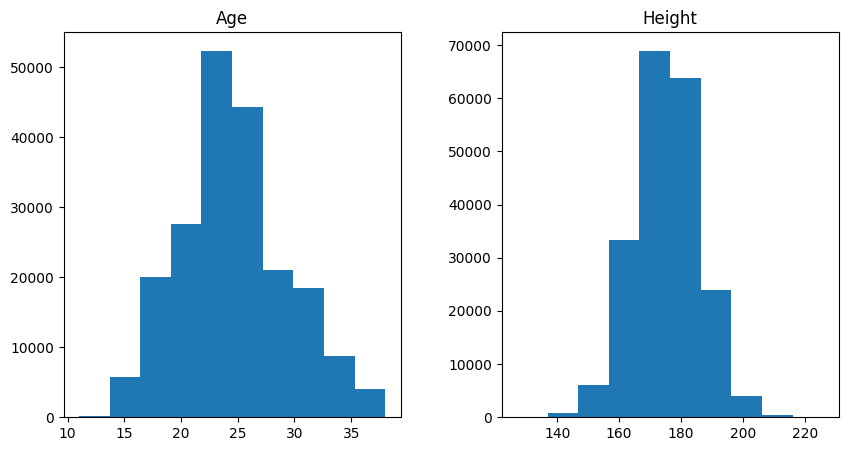

In [59]:
df3[['Age','Height']].hist(figsize=(10,5), grid=False)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Age-scaled'}>]], dtype=object)

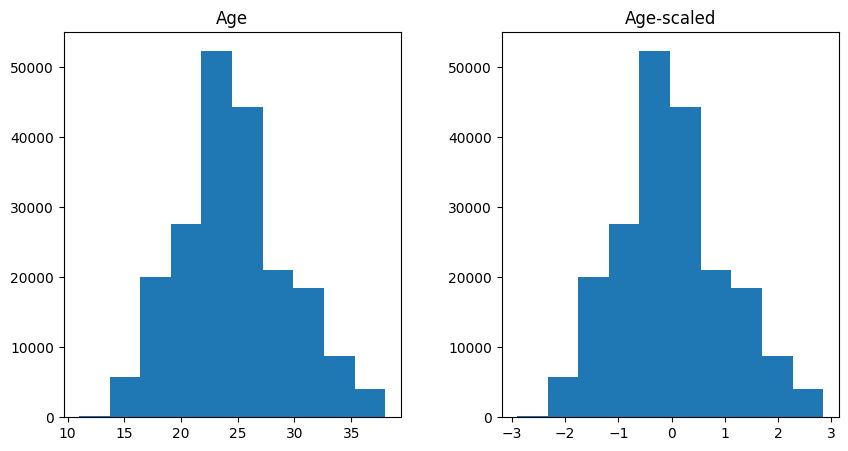

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df3[['Age']]
df3['Age-scaled'] = scaler.fit_transform(X)
df3[['Age','Age-scaled']].hist(figsize=(10,5), grid=False)

array([[<Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Height-robust-scaled'}>]], dtype=object)

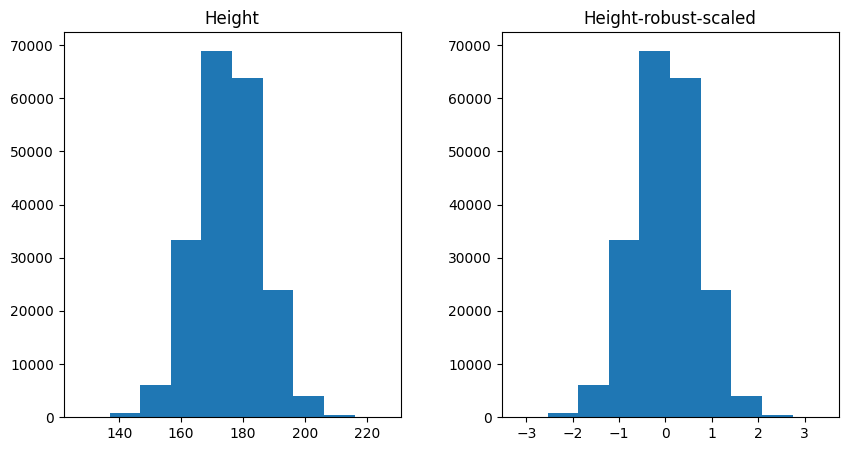

In [ ]:
from sklearn.preprocessing import RobustScaler
#No quitamos outliers entonces usamos robustscaler
scaler = RobustScaler() 
XH= df3[['Height']]
df3['Height-robust-scaled'] = scaler.fit_transform(XH)
df3[['Height','Height-robust-scaled']].hist(figsize=(10,5), grid=False)


In [73]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202694 entries, 0 to 271115
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Sport                 202694 non-null  object 
 1   Sex                   202694 non-null  object 
 2   Weight                202694 non-null  float64
 3   Age-scaled            202694 non-null  float64
 4   Height-robust-scaled  201534 non-null  float64
dtypes: float64(3), object(2)
memory usage: 9.3+ MB


Al final debe obtener un arrego numérico con la matriz de características procesadas.

**Reporte el tamaño de este arreglo**.

In [85]:
df_sex = df3[['Sex']]

ohe = OneHotEncoder(
    sparse_output=False,
    drop='if_binary'
    )

sex = ohe.fit_transform(df_sex)

columns = ohe.get_feature_names_out()

df_sex_cod = pd.DataFrame(
    data = sex,
    columns = columns
    )

df_sex_cod.head()

,Sex_M
0,1.0
1,1.0
2,0.0
3,0.0
4,0.0


In [87]:
arreglo_numerico = df3.values
print(f"El tamaño del arreglo numérico es: {arreglo_numerico.shape}")

El tamaño del arreglo numérico es: (202694, 5)


Entrene un modelo de regresión de vecinos más cercanos (clase `KNeighborsRegressor`) con la matriz de características creada.

Reporte el score del modelo con los datos de prueba.

---

Train a nearest neighbor regression model ('KNeighborsRegressor' class) with the created feature matrix.

Report the model score with the test data.

In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

df_para_modelo = pd.concat([
    df3[['Age-scaled', 'Height-robust-scaled', 'Weight']], 
    df_sporte_cod, 
    df_sex_cod
], axis=1)
df_para_modelo = df_para_modelo.dropna()
X = df_para_modelo.drop(columns=['Weight'])
y = df_para_modelo['Weight']

arreglo_final = X.values
print(f"El tamaño del arreglo numérico procesado es: {arreglo_final.shape}")


El tamaño del arreglo numérico procesado es: (150304, 30)


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 6. ENTRENAMIENTO DEL MODELO
model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)


# 7. REPORTE DEL SCORE CON DATOS DE PRUEBA
score_test = model_knn.score(X_test, y_test)
print(f"El score del modelo (R^2) con los datos de prueba es: {score_test:.4f}")

print(model_knn.score(X_train, y_train))
print(model_knn.score(X_test, y_test))


El score del modelo (R^2) con los datos de prueba es: 0.7086
0.7692865737946222
0.7086128223744341


**Condiciones de entrega:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

---

**Delivery Terms:**

- You must submit a file in .ipynb format.
- The code must run correctly when the cells are executed sequentially.
- You must deliver the code already executed.
- Remove all code that was junk, only deliver code that responds to what you are asked to do.